In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison
import seaborn as sb


In [ ]:
# ============================================================
# Ajuste de coeficientes de matriz IP utilizando datos de trabajadores asegurados
# Chunk 2: Definición de sectores + carga y preprocesamiento inicial
# ============================================================

# ------------------------------------------------------------------
# 1) Nombres de sectores (mapeo visual para códigos sectoriales)
# ------------------------------------------------------------------
sector_names = [
    "Industrias Agropecuaria",
    "Industrias Extractivas",
    "",  # TODO (INVESTIGAR): hay un sector sin etiqueta. Debido a que en la lista oficial de sectores del IMSS,
         # Industrias de transformación se repite dos veces, entonces para que no haya error.
    "Industrias de Transformacion",
    "Industrias de la Construccion",
    "Ind. Electrica y Suministro Agua pot",
    "Comercio",
    "Transporte y comunicaciones",
    "Servicios para empresa, personal, hogar",
    "Servicios sociales"
]

# Nota técnica:
# - Si los códigos sectoriales inician en 1 (en lugar de 0), esta lista puede desfasarse.
# - Confirmar más adelante contra los valores reales en `sector_economico_1` y `sector_economico_2`.

# ------------------------------------------------------------------
# 2) Carga de datos
# ------------------------------------------------------------------
# En Colab, asegúrate de que el archivo exista en la ruta especificada.
# Si se monta Google Drive, ajustar `DATA_PATH` adecuadamente.
DATA_PATH = "./HW_Datos_Jal.csv"

data = pd.read_csv(DATA_PATH)

# TODO (INVESTIGAR): Confirmar qué representa el dataset "HW_Datos_Jal.csv":
# - Fuente (IMSS, INEGI, otra)
# - Cobertura geográfica (¿Jalisco?)
# - Cobertura temporal
# - Definición de variables, especialmente HWES1 y Año.

# ------------------------------------------------------------------
# 3) Copia de trabajo + renombre de variable clave
# ------------------------------------------------------------------
data_hw = data.copy()

# HWES1 parece ser la variable central que luego interpretan como "ta".
# TODO (INVESTIGAR): ¿Qué es HWES1 exactamente?
# Posibles hipótesis:
# - "Trabajadores asegurados" (IMSS) en cierto sector
# - Alguna medida de empleo formal / asegurados
data_hw["ta"] = data_hw["HWES1"]
data_hw = data_hw.drop(columns=["HWES1"])

# ------------------------------------------------------------------
# 4) Selección de variables relevantes + limpieza de nulos
# ------------------------------------------------------------------
cols_needed = ["sector_economico_1", "sector_economico_2", "ta", "Año"]

# Filtramos a las columnas necesarias y quitamos filas con NA en esas columnas.
selected_data = data_hw.loc[:, cols_needed].dropna()

# TODO (INVESTIGAR): Confirmar qué son:
# - sector_economico_1 y sector_economico_2:
#   ¿Origen? ¿codificación? ¿representan "origen-destino" o "sector i - sector j"?

# ------------------------------------------------------------------
# 5) Tratamiento del tiempo y filtro temporal (post-2010-01-31)
# ------------------------------------------------------------------
# Convertimos explícitamente la columna de fecha.
# Si no es una fecha, esto revelará errores temprano (mejor que errores silenciosos).
selected_data["Año"] = pd.to_datetime(selected_data["Año"], errors="coerce")

# Eliminamos filas donde la fecha no pudo convertirse
selected_data = selected_data.dropna(subset=["Año"])

# Aplicamos filtro temporal
cutoff_date = pd.Timestamp("2010-01-31")
selected_data = selected_data[selected_data["Año"] > cutoff_date]  # No es necesario aplicar filtro porque los datos comienzan en febrero 2010

# Vista rápida
selected_data.head()


,sector_economico_1,sector_economico_2,ta,Año
0,0.0,1.0,40878.000000,2010-02-28
1,0.0,1.0,40878.000000,2010-03-31
2,0.0,1.0,40913.125000,2010-04-30
3,0.0,1.0,40804.703125,2010-05-31
4,0.0,1.0,40651.132161,2010-06-30


In [ ]:
def get_sector_data_covars(data: pd.DataFrame):
    # Se hace una copia del DataFrame para evitar modificar el original fuera de la función
    data = data.copy()

    # ------------------------------------------------------------
    # 1) "Main sector data": agregación por sector principal y tiempo
    # ------------------------------------------------------------
    # Agrupa por (Año, sector_economico_1) y suma las columnas numéricas dentro de cada grupo.
    # Resultado esperado: una fila por (Año, sector_economico_1) con el total de 'ta' (y cualquier
    # otra variable numérica que exista en el DataFrame).
    #
    # NOTA: aquí se usa .sum() sin seleccionar columnas, así que sumará todas las numéricas.
    sector_data = data.groupby(["Año", "sector_economico_1"])\
        .sum() \
        .reset_index() \
        .drop("sector_economico_2", axis=1) \
        .sort_values(by=["sector_economico_1", "Año"])

    # ------------------------------------------------------------
    # 2) "Groups data": agregación por sector principal, sector secundario y tiempo
    # ------------------------------------------------------------
    # Agrupa por (Año, sector_economico_1, sector_economico_2) y suma columnas numéricas.
    # Resultado: una fila por combinación sector-sector en cada Año, con su 'ta' agregado.
    grouped_data = data.groupby(["Año", "sector_economico_1", "sector_economico_2"])\
        .sum() \
        .reset_index()

    # ------------------------------------------------------------
    # 3) Base de retorno
    # ------------------------------------------------------------
    # ret_data empieza siendo igual a sector_data (actividad agregada del sector principal por Año)
    # y luego se le agregan columnas "covar_*" (covariables) para cada grupo sectorial.
    ret_data = sector_data.copy()

    # print(ret_data)  # útil para depurar si se quiere ver la estructura base

    # ------------------------------------------------------------
    # 4) Identificar sectores principales disponibles
    # ------------------------------------------------------------
    # Obtiene la lista de sectores únicos en sector_economico_1 para iterar sector por sector.
    sectors_set = sorted(set(sector_data.sector_economico_1))

    # ------------------------------------------------------------
    # 5) Agregar covariables por sector y "grupo"
    # ------------------------------------------------------------
    # Por cada sector principal:
    #   - se identifican los grupos (sector_economico_2) que aparecen asociados a ese sector
    #   - se obtiene la serie de 'ta' para cada par (sector, grupo) a lo largo del tiempo
    #   - se crea una nueva columna en ret_data con nombre covar_s{sector}_g{grupo}
    for sector in sectors_set:
        # Lista de grupos asociados al sector principal "sector"
        groups_set = sorted(set(
            grouped_data[(grouped_data["sector_economico_1"] == sector)]["sector_economico_2"]
        ))

        for group in groups_set:
            # Extrae la serie de 'ta' para el par (sector_economico_1=sector, sector_economico_2=group)
            # a través del tiempo (Año).
            employments_per_group = grouped_data[
                (grouped_data["sector_economico_1"] == sector) &
                (grouped_data["sector_economico_2"] == group)
            ]["ta"]

            try:
                # Convierte la serie a lista y la repite 10 veces.
                # Este paso NO alinea por Año; es un método para forzar dimensión/longitud
                # para que el vector encaje en el DataFrame ret_data.
                #
                # TODO (INVESTIGAR / DOCUMENTAR):
                # ¿Por qué multiplicar por 10? ¿Representa número de años, periodos u otra razón técnica?
                covar_col = list(employments_per_group.values) * 10

                # Crea una nueva columna con el patrón covar_s{sector}_g{group}
                # Interpretación: esta columna sirve como covariable (posible explicativa) asociada
                # al empleo del grupo "group" dentro del sector principal "sector".
                ret_data[f"covar_s{int(sector)}_g{int(group)}"] = covar_col

            except Exception as e:
                # Si la asignación falla (normalmente por diferencias de longitud entre covar_col y ret_data),
                # se imprime un mensaje y se omite ese grupo para ese sector.
                #
                # NOTA: Esto puede provocar que falten covariables en el resultado final sin detener el programa.
                print(
                    f"Skipping sector {sector_names[int(sector)]} group {group}, "
                    f"it does not contain the same amount of rows: {len(employments_per_group)}"
                )

    # ------------------------------------------------------------
    # 6) Salida de la función
    # ------------------------------------------------------------
    # Devuelve ret_data: una tabla por (Año, sector_economico_1) con 'ta' agregado
    # + columnas covar_sX_gY que representan series de empleo por grupo (replicadas).
    return ret_data


In [ ]:
sector_data = data.groupby(["Año", "sector_economico_1"])\
        .sum() \
        .reset_index() \
        .drop("sector_economico_2", axis=1) \
        .sort_values(by=["sector_economico_1", "Año"])
sector_data

,Año,sector_economico_1,Unnamed: 0,ta,HWES1
0,2010-02-28,0.0,1620,57171,57171.000000
10,2010-03-31,0.0,1625,58078,57171.000000
20,2010-04-30,0.0,1630,54776,57208.791667
30,2010-05-31,0.0,1635,53586,57107.425347
40,2010-06-30,0.0,1640,54004,56960.699291
...,...,...,...,...,...
1579,2023-03-31,9.0,47940,283818,273669.743647
1589,2023-04-30,9.0,47945,283923,274092.587662
1599,2023-05-31,9.0,47950,283704,274502.188176
1609,2023-06-30,9.0,47955,280589,274885.597002


In [ ]:
#grouped_data = data.groupby(["Año", "sector_economico_1", "sector_economico_2"])\
        #.sum() \
        #.reset_index()

sectors_set = sorted(set(sector_data.sector_economico_1))
for sector in sectors_set:
        # Lista de grupos asociados al sector principal "sector"
        groups_set = sorted(set(
            grouped_data[(grouped_data["sector_economico_1"] == sector)]["sector_economico_2"]
        ))

        for group in groups_set:
            # Extrae la serie de 'ta' para el par (sector_economico_1=sector, sector_economico_2=group)
            # a través del tiempo (Año).
            employments_per_group = grouped_data[
                (grouped_data["sector_economico_1"] == sector) &
                (grouped_data["sector_economico_2"] == group)
            ]["ta"]


In [ ]:
sector_df = get_sector_data_covars(selected_data)
sector_df.head()

,Año,sector_economico_1,ta,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,...,covar_s8_g85,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99
0,2010-02-28,0.0,57171.000000,40878.000000,15525.000000,448.000000,314.000000,6.0,1383.000000,5.0,...,3926.000000,21884.000000,33623.000000,11836.000000,35783.000000,39956.000000,17662.000000,5346.000000,162505.000000,117.000000
10,2010-03-31,0.0,57171.000000,40878.000000,15525.000000,448.000000,314.000000,6.0,1383.000000,5.0,...,3926.000000,21884.000000,33623.000000,11836.000000,35783.000000,39956.000000,17662.000000,5346.000000,162505.000000,117.000000
20,2010-04-30,0.0,57208.791667,40913.125000,15525.333333,450.875000,313.458333,6.0,1382.750000,5.0,...,3921.583333,21871.125000,33609.541667,11839.750000,35782.000000,39928.958333,17681.833333,5352.000000,162521.125000,117.041667
30,2010-05-31,0.0,57107.425347,40804.703125,15529.986111,453.130208,313.605903,6.0,1381.302083,5.0,...,3917.392361,21846.286458,33596.269097,11840.802083,35773.958333,39885.668403,17716.506944,5363.666667,162551.744792,117.164931
40,2010-06-30,0.0,56960.699291,40651.132161,15537.486690,451.749783,314.330657,6.0,1380.622830,5.0,...,3918.001013,21815.191189,33585.549552,11846.351997,35774.001736,39829.848886,17754.069155,5371.222222,162607.922092,117.283058


In [ ]:

# ------------------------------------------------------------
# 1) Construcción del dataset por sector con covariables
# ------------------------------------------------------------
sector_df = get_sector_data_covars(selected_data)

# Las primeras columnas esperadas suelen ser: ["Año", "sector_economico_1", "ta"]
# pero esto es un supuesto: confirmarlo si cambia el orden.
# Tomamos desde la 4ta columna en adelante como covariables (grupos).
covars_df = sector_df.iloc[:, 3:].copy()

# ------------------------------------------------------------
# TODO (INVESTIGAR): ¿Por qué cortar a 162 filas?
# - Puede ser para quedarse con un periodo común entre sectores/grupos.
# - Puede ser número de observaciones esperadas (p.ej. meses).
# Si necesitas replicar exactamente, déjalo; si no, mejor justificarlo o hacerlo dinámico.
# ------------------------------------------------------------
covars_df = covars_df.iloc[:162, :].copy()

# Lista de covariables
covars = list(covars_df.columns)

# ------------------------------------------------------------
# 2) Estimación: para cada covariable c, se estima:
#    c_t = α + Σ_{k≠c} β_k * k_t + error
#
# Esto genera una "matriz" de coeficientes β entre covariables.
# Interpretación: asociación/relación estadística condicional, no flujos insumo-producto.
# ------------------------------------------------------------

rows = []  # aquí guardaremos cada fila de coeficientes como una Serie

for c in covars:
    # Variable dependiente
    y = covars_df[c]

    # Variables explicativas: todas menos la dependiente
    X = covars_df.drop(columns=[c])

    # Intercepto
    X = sm.add_constant(X, has_constant="add")

    # Modelo OLS
    mod = sm.OLS(y, X)

    # Ajuste regularizado (tipo L1/L2 dependiendo parámetros por defecto)
    # TODO (INVESTIGAR): ¿qué penalización usa el notebook original? ¿alpha? ¿L1_wt?
    res = mod.fit_regularized()

    params = res.params.copy()

    # Intercepto
    const = params.get("const", 0.0)

    # Coefs sin intercepto
    coef_series = params.drop(labels=["const"], errors="ignore")

    # ------------------------------------------------------------
    # Comportamiento original: guardan el intercepto en una entrada con nombre 'c'
    # (parece que buscan una "diagonal" o algo equivalente).
    # TODO (INVESTIGAR): confirmar si esta convención es intencional.
    # Alternativa más clara: guardar intercepto como columna "intercept".
    # ------------------------------------------------------------
    coef_series[c] = const

    # Nombrar la fila con el nombre de la variable dependiente
    coef_series.name = c

    rows.append(coef_series)

# Construcción final del DataFrame de coeficientes
coeffs_df = pd.DataFrame(rows).sort_index(axis=0).sort_index(axis=1)
covars_df = covars_df.replace([np.inf, -np.inf], np.nan).fillna(0)

coeffs_df.head()


,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g85,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99
covar_s0_g1,60259.249098,0.173001,-3.827673,-3.062745,621.914672,-8.226210,314.560722,3.048369,-0.046280,-0.088673,...,0.015414,0.009803,0.019338,0.016371,-0.018651,-0.014522,0.040648,-0.085941,-0.004444,-3.032327
covar_s0_g2,0.016808,17960.411944,-2.644416,2.693786,60.297486,-1.129978,64.980354,-0.015372,-0.002264,-0.000200,...,0.051334,-0.003958,-0.001228,-0.003405,-0.001115,-0.002948,0.013389,-0.069717,0.000958,-0.730983
covar_s0_g3,-0.000026,-0.000580,463.848170,-0.119206,1.160594,0.015955,-2.205729,0.033051,-0.000337,-0.000342,...,-0.001128,0.000300,0.000096,0.000332,-0.000070,0.000013,-0.000400,0.002821,-0.000072,0.023041
covar_s0_g4,-0.000014,0.001427,-0.163182,279.060954,4.084992,-0.017413,1.643056,-0.104916,0.001573,0.001464,...,0.001935,-0.000788,-0.000484,-0.000790,0.000690,-0.000092,0.002027,-0.008882,0.000174,0.118623
covar_s0_g5,0.000116,-0.000223,-0.005661,0.010551,17.909151,-0.002399,0.270012,0.000346,0.000021,-0.000112,...,0.000003,-0.000018,0.000022,-0.000021,-0.000011,-0.000014,0.000057,-0.000397,0.000000,0.004667


## Buscando correlaciones con datos PIB Inegi.

In [ ]:
# ------------------------------------------------------------
# Sección: Buscando correlaciones con datos PIB INEGI
# ------------------------------------------------------------

# Se carga el archivo CSV con datos de PIB provenientes de INEGI.
# Por el nombre del archivo ("Inegi_T1_4.csv"), se infiere que:
# - La fuente es INEGI
# - Los datos corresponden al PIB
# - La periodicidad podría ser trimestral (T1 a T4)
#
# TODO (INVESTIGAR / DOCUMENTAR):
# - Fuente exacta dentro de INEGI (cuentas nacionales, base específica)
# - Unidad de medida del PIB (precios corrientes, constantes, índice, etc.)
# - Cobertura temporal y sectorial
gdp_data = pd.read_csv("./Inegi_T1_4.csv")

# Se eliminan la primera fila y la primera columna del DataFrame.
# Esto suele hacerse cuando:
# - La primera fila contiene encabezados adicionales, títulos o notas
# - La primera columna contiene etiquetas no numéricas (por ejemplo, nombres de sectores)
#
# Este paso asume que los datos "útiles" comienzan a partir de la fila 1 y columna 1.
# Es un ajuste manual dependiente del formato específico del archivo CSV.
gdp_data = gdp_data.iloc[1:, 1:]

# Vista preliminar del DataFrame resultante para inspección visual.
# Permite verificar la estructura de los datos (filas, columnas, valores).
gdp_data.head()


,Año,2010,2010.1,2010.2,2010.3,2011,2011.1,2011.2,2011.3,2012,...,2021,2021.1,2021.2,2021.3,2022,2022.1,2022.2,2022.3,2023,2023.1
1,111 - Agricultura,341063.915,466580.473,323870.597,441958.107,348272.583,385824.919,318443.223,447012.131,362824.69,...,477743.922,578813.189,415695.969,640313.04,479049.254,579839.641,426250.972,701909.52,488775.444,591658.916
2,112 - Cría y explotación de animales,214645.198,223598.046,234879.545,238910.775,215917.756,222477.047,240570.103,244816.258,221174.899,...,242709.508,254639.865,267938.055,277542.248,249258.696,261415.555,274393.947,284041.31,253409.793,266599.246
3,113 - Aprovechamiento forestal,19079.724,21394.82,19462.358,22108.726,17950.593,21743.678,19328.217,22465.264,18966.265,...,23428.257,23986.87,24326.465,25371.856,24263.069,22407.379,23115.518,24798.09,23132.752,21717.916
4,"114 - Pesca, caza y captura",7107.197,6707.911,6137.927,9152.373,5121.073,5912.703,7585.554,10746.925,5531.222,...,6810.759,7283.117,7280.347,10999.322,6952.323,6216.735,6851.943,10496.633,6745.127,6637.909
5,115 - Servicios relacionados con las actividad...,4618.411,4732.202,3932.631,4132.972,4069.119,4043.908,3875.472,4637.461,4563.828,...,5585.123,5730.783,5096.244,7310.447,5728.803,5692.767,4918.594,7268.778,6099.641,5808.053


In [ ]:
# ------------------------------------------------------------
# Selección de datos comparables para análisis con PIB
# ------------------------------------------------------------

# Se seleccionan únicamente las columnas relevantes para el análisis:
# - sector_economico_1: sector principal
# - sector_economico_2: sector asociado o grupo
# - ta: trabajadores asegurados (proxy de actividad económica)
# - Año: variable temporal
#
# Primero se eliminan filas con valores faltantes en cualquier columna del DataFrame.
selected_comp_data = data.dropna().loc[:, [
    "sector_economico_1",
    "sector_economico_2",
    "ta",
    "Año"
]]

# Se filtran las observaciones para conservar únicamente datos posteriores
# al 31 de enero de 2010.
#
# NOTA:
# Aquí la comparación se hace contra un string ("2010-01-31").
# Esto asume implícitamente que la columna "Año" está en un formato
# comparable lexicográficamente (por ejemplo, YYYY-MM-DD).
selected_comp_data = selected_comp_data[selected_comp_data["Año"] > "2010-01-31"]

# Vista preliminar del DataFrame filtrado
selected_comp_data.head()


,sector_economico_1,sector_economico_2,ta,Año
0,0.0,1.0,40878,2010-02-28
1,0.0,1.0,41721,2010-03-31
2,0.0,1.0,38311,2010-04-30
3,0.0,1.0,37119,2010-05-31
4,0.0,1.0,37401,2010-06-30


In [ ]:
# ------------------------------------------------------------
# Submuestra para inspección / comparación puntual
# ------------------------------------------------------------

# Se construye una submuestra específica fijando:
# - sector_economico_1 == 0
# - sector_economico_2 == 1
#
# El objetivo aquí parece ser analizar un par concreto de sectores
# (sector principal 0 con sector asociado 1) a lo largo del tiempo,
# posiblemente para compararlo con la evolución del PIB.
sample_data = selected_comp_data[
    (selected_comp_data["sector_economico_1"] == 0.) &
    (selected_comp_data["sector_economico_2"] == 1.)
]

# Se convierte explícitamente la columna "Año" a formato datetime.
# Esto sugiere que, a partir de aquí, el tiempo será tratado
# como una variable temporal real (series de tiempo, gráficos, etc.).
sample_data["Año"] = pd.to_datetime(sample_data["Año"])

# Vista preliminar de la submuestra
sample_data.head()


/tmp/ipython-input-1096938434.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data["Año"] = pd.to_datetime(sample_data["Año"])


,sector_economico_1,sector_economico_2,ta,Año
0,0.0,1.0,40878,2010-02-28
1,0.0,1.0,41721,2010-03-31
2,0.0,1.0,38311,2010-04-30
3,0.0,1.0,37119,2010-05-31
4,0.0,1.0,37401,2010-06-30


In [ ]:
# ------------------------------------------------------------
# Agregación temporal de empleo asegurado a frecuencia trimestral
# ------------------------------------------------------------

# A partir de sample_data (un par específico de sectores),
# se agrupa la variable 'ta' por trimestre.
#
# sample_data['Año'].dt.to_period('Q'):
#   - Convierte la fecha a un periodo trimestral (Q1, Q2, Q3, Q4)
#   - Esto permite alinear la frecuencia temporal con el PIB trimestral del INEGI.
sample_grouped = (
    sample_data
        .groupby(sample_data['Año'].dt.to_period('Q'))['ta']
        .sum()
        # Se eliminan el primer y último trimestre del resultado.
        # Esto suele hacerse para:
        # - eliminar trimestres incompletos,
        # - o alinear longitudes con otra serie temporal (PIB).
        .iloc[1:-1]
)

# ------------------------------------------------------------
# Comparación de dimensiones entre empleo y PIB
# ------------------------------------------------------------

# Se compara la longitud de la serie trimestral de empleo asegurado
# contra la longitud de una fila del DataFrame de PIB.
#
# sample_grouped.values.shape:
#   - dimensión de la serie trimestral de 'ta'
#
# gdp_data.iloc[0, 2:].values.shape:
#   - dimensión de la serie de PIB (a partir de la columna 2),
#     probablemente correspondiente a un sector específico.
#
# El objetivo implícito es verificar que ambas series
# tengan la misma longitud para poder compararlas o correlacionarlas.
sample_grouped.values.shape, gdp_data.iloc[0, 2:].values.shape


((53,), (53,))

In [ ]:
# ------------------------------------------------------------
# Construcción de DataFrame comparable IMSS vs INEGI
# ------------------------------------------------------------

# Se construye un nuevo DataFrame con dos columnas:
# - "imss": serie trimestral de empleo asegurado (IMSS),
#           obtenida previamente al agrupar 'ta' por trimestre.
# - "inegi": serie de PIB proveniente de INEGI, convertida explícitamente a float.
#
# Se asume implícitamente que:
# - Ambas series tienen la MISMA longitud
# - Están ALINEADAS en el tiempo (mismo número de trimestres y mismo orden)
#
# NOTA IMPORTANTE:
# - No se hace una validación explícita de fechas o periodos.
# - La alineación se garantiza únicamente porque antes se compararon las dimensiones.
comp_data = pd.DataFrame({
    "imss": list(sample_grouped.values),
    "inegi": list(map(lambda x: float(x), gdp_data.iloc[0, 2:].values))
})

# ------------------------------------------------------------
# Cálculo de correlación
# ------------------------------------------------------------

# Se calcula la matriz de correlación entre las dos series.
# Por defecto, pandas utiliza correlación de Pearson.
#
# Interpretación esperada:
# - Un coeficiente cercano a 1 indica alta correlación positiva
# - Cercano a 0 indica poca o nula relación lineal
# - Cercano a -1 indica correlación negativa
comp_data.corr()


,imss,inegi
imss,1.000000,0.573265
inegi,0.573265,1.000000


<Axes: >

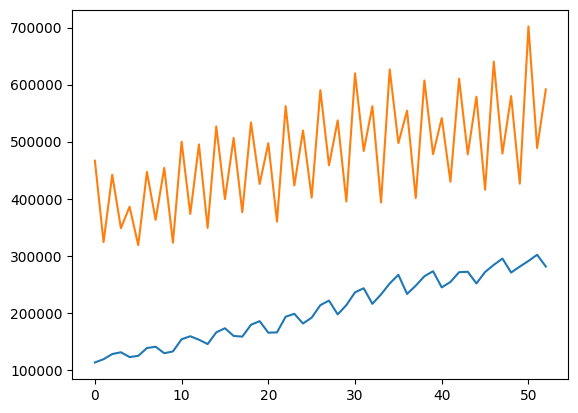

In [ ]:
# ------------------------------------------------------------
# Visualización exploratoria de las series IMSS vs INEGI
# ------------------------------------------------------------

# Gráfica de la serie trimestral de empleo asegurado (IMSS)
# El objetivo es observar:
# - tendencia general
# - estacionalidad
# - posibles rupturas estructurales
comp_data["imss"].plot()

# Gráfica de la serie trimestral de PIB (INEGI)
# Se grafica sobre la misma figura por defecto,
# permitiendo una comparación visual directa entre ambas series.
comp_data["inegi"].plot()


In [ ]:
# ------------------------------------------------------------
# Regresión lineal simple: IMSS ~ PIB (INEGI)
# ------------------------------------------------------------

# Se agrega explícitamente una constante (intercepto) al DataFrame.
# Esto permite estimar un modelo con término constante:
#   imss = α + β * inegi + error
comp_data["const"] = np.ones(len(comp_data))

# Se define el modelo OLS (Ordinary Least Squares):
# - Variable dependiente: empleo asegurado (IMSS)
# - Variable explicativa: PIB (INEGI)
# - Incluye intercepto ('const')
#
# NOTA:
# Se pasan los valores como arreglos NumPy, no como Series con índice,
# por lo que la alineación depende exclusivamente del orden de las filas.
model = sm.OLS(
    comp_data.loc[:, "imss"].values,
    comp_data.loc[:, ["const", "inegi"]]
)

# Se ajusta el modelo por mínimos cuadrados ordinarios
res = model.fit()

# Se muestra el resumen completo de la regresión:
# coeficientes, errores estándar, R², estadísticos t, p-values, etc.
res.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     24.96
Date:                Thu, 29 Jan 2026   Prob (F-statistic):           7.24e-06
Time:                        23:34:56   Log-Likelihood:                -644.72
No. Observations:                  53   AIC:                             1293.
Df Residuals:                      51   BIC:                             1297.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         3.7e+04   3.43e+04      1.079      0.286   -3.18e+04    1.06e+05
inegi          0.3526      0.071      4.996      0.000       0.211       0.494
==============================================================================
Omnibus:                        2.891   Durbin-Watson:                   1.317
Prob(Omnibus):                  0.236   Jarque-Bera (JB):                2.218
Skew:                           0.349   Prob(JB):                        0.330
Kurtosis:                       2.281   Cond. No.                     2.56e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.56e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Estandarizando la matriz de Coeficientes

Porcentaje de impacto entre grupos

In [ ]:
coeffs_df.head()



,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g85,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99
covar_s0_g1,60259.249098,0.173001,-3.827673,-3.062745,621.914672,-8.226210,314.560722,3.048369,-0.046280,-0.088673,...,0.015414,0.009803,0.019338,0.016371,-0.018651,-0.014522,0.040648,-0.085941,-0.004444,-3.032327
covar_s0_g2,0.016808,17960.411944,-2.644416,2.693786,60.297486,-1.129978,64.980354,-0.015372,-0.002264,-0.000200,...,0.051334,-0.003958,-0.001228,-0.003405,-0.001115,-0.002948,0.013389,-0.069717,0.000958,-0.730983
covar_s0_g3,-0.000026,-0.000580,463.848170,-0.119206,1.160594,0.015955,-2.205729,0.033051,-0.000337,-0.000342,...,-0.001128,0.000300,0.000096,0.000332,-0.000070,0.000013,-0.000400,0.002821,-0.000072,0.023041
covar_s0_g4,-0.000014,0.001427,-0.163182,279.060954,4.084992,-0.017413,1.643056,-0.104916,0.001573,0.001464,...,0.001935,-0.000788,-0.000484,-0.000790,0.000690,-0.000092,0.002027,-0.008882,0.000174,0.118623
covar_s0_g5,0.000116,-0.000223,-0.005661,0.010551,17.909151,-0.002399,0.270012,0.000346,0.000021,-0.000112,...,0.000003,-0.000018,0.000022,-0.000021,-0.000011,-0.000014,0.000057,-0.000397,0.000000,0.004667


In [ ]:
# Se aplica una transformación fila por fila (axis=1) sobre la matriz de coeficientes.
# Cada fila x corresponde a los coeficientes estimados para una regresión específica
# (es decir, para un grupo/sector explicado por los demás).
coeffs_std = coeffs_df.apply(lambda x: x / sum(abs(x)), axis=1)
coeffs_std

,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g85,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99
covar_s0_g1,9.840963e-01,2.825282e-06,-0.000063,-0.000050,0.010157,-0.000134,0.005137,4.978304e-05,-7.557931e-07,-1.448119e-06,...,2.517317e-07,1.601005e-07,3.158113e-07,2.673621e-07,-3.045974e-07,-2.371567e-07,6.638278e-07,-1.403507e-06,-7.257813e-08,-0.000050
covar_s0_g2,9.289013e-07,9.925830e-01,-0.000146,0.000149,0.003332,-0.000062,0.003591,-8.495286e-07,-1.251431e-07,-1.103226e-08,...,2.836958e-06,-2.187577e-07,-6.788033e-08,-1.881922e-07,-6.163171e-08,-1.629318e-07,7.399708e-07,-3.852915e-06,5.291855e-08,-0.000040
covar_s0_g3,-5.474493e-08,-1.241722e-06,0.992274,-0.000255,0.002483,0.000034,-0.004719,7.070397e-05,-7.212906e-07,-7.308376e-07,...,-2.413019e-06,6.422801e-07,2.048886e-07,7.110022e-07,-1.499195e-07,2.777221e-08,-8.549892e-07,6.035315e-06,-1.539803e-07,0.000049
covar_s0_g4,-4.870939e-08,4.996106e-06,-0.000571,0.977026,0.014302,-0.000061,0.005753,-3.673243e-04,5.508394e-06,5.125784e-06,...,6.775397e-06,-2.758150e-06,-1.695350e-06,-2.766661e-06,2.416916e-06,-3.224453e-07,7.097413e-06,-3.109763e-05,6.074606e-07,0.000415
covar_s0_g5,6.357597e-06,-1.221925e-05,-0.000311,0.000579,0.982596,-0.000132,0.014814,1.895945e-05,1.152501e-06,-6.141640e-06,...,1.379763e-07,-9.728356e-07,1.194806e-06,-1.160653e-06,-5.888811e-07,-7.545284e-07,3.122108e-06,-2.178617e-05,0.000000e+00,0.000256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
covar_s9_g91,4.913323e-07,-1.422481e-06,0.000025,-0.000195,0.003714,-0.000020,0.000947,2.355159e-05,-3.743936e-07,-5.804236e-07,...,-6.925265e-07,1.387899e-07,1.810259e-07,2.210157e-07,-2.042908e-07,9.949157e-01,-3.965464e-07,1.803311e-06,-4.779074e-08,-0.000027
covar_s9_g92,1.363566e-06,-2.335987e-06,-0.000086,0.000223,0.004230,-0.000095,0.000890,1.984254e-05,-3.326005e-08,-3.251547e-08,...,3.485805e-06,2.572834e-07,-7.576928e-08,1.798032e-07,-1.303294e-07,-2.722158e-07,9.941262e-01,1.049660e-06,-1.632674e-08,0.000005
covar_s9_g93,2.224529e-07,-1.407341e-06,0.000088,-0.000284,0.001484,0.000019,-0.000691,7.302890e-05,-1.137706e-06,-7.370085e-07,...,-1.247073e-06,5.476783e-07,9.693801e-08,1.050138e-06,-1.134784e-07,-1.474263e-07,5.691694e-08,9.970232e-01,2.993820e-09,0.000065
covar_s9_g94,4.009587e-07,-8.670774e-07,-0.000008,-0.000035,0.001799,-0.000019,0.000559,2.306467e-05,-3.495590e-07,-3.511436e-07,...,-5.064531e-08,5.707416e-08,5.391701e-08,1.937149e-07,-5.210784e-08,-8.185007e-08,1.551054e-07,5.540265e-07,9.974129e-01,-0.000050


### Lineas de tendencia sectoriales


In [ ]:
# ------------------------------------------------------------
# Selección de observaciones de diciembre y agregación anual
# ------------------------------------------------------------

# Se convierte explícitamente la columna "Año" a formato datetime.
# Esto permite extraer componentes temporales como el mes.
selected_data["Año"] = pd.to_datetime(selected_data["Año"])

# Se filtran únicamente las observaciones correspondientes al mes de diciembre.
# La idea implícita es usar diciembre como un "representante anual"
# del nivel de empleo asegurado de cada sector.
dec_data = (
    selected_data[selected_data["Año"].dt.month == 12]
        # Se agrupa por Año y sector principal
        .groupby(["Año", "sector_economico_1"])
        # Se suman las variables numéricas dentro de cada grupo
        .sum()
        # Se elimina la columna sector_economico_2, ya que no es relevante
        # después de la agregación anual por sector principal
        .drop("sector_economico_2", axis=1)
        # Se reinicia el índice para obtener un DataFrame plano
        .reset_index()
)

# Se muestra el DataFrame resultante
dec_data


,Año,sector_economico_1,ta
0,2010-12-31,0.0,57000.936713
1,2010-12-31,1.0,2179.192215
2,2010-12-31,2.0,151602.027532
3,2010-12-31,3.0,163108.305877
4,2010-12-31,4.0,88007.498456
...,...,...,...
125,2022-12-31,5.0,9672.675313
126,2022-12-31,6.0,374868.453596
127,2022-12-31,7.0,92834.640013
128,2022-12-31,8.0,352071.114729


In [ ]:
# ------------------------------------------------------------
# Carga y preparación de datos de PIB estatal (Jalisco) por actividad
# ------------------------------------------------------------

# Se carga un archivo de Excel con datos de PIB de Jalisco por actividad económica.
# El parámetro skiprows=4 indica que las primeras 4 filas del archivo
# contienen encabezados, notas o metadatos que no forman parte de los datos tabulares.
pib_jal = pd.read_excel(
    "./pib_jalisco_actividad.xlsx",
    skiprows=4
)

# Se selecciona un subconjunto del DataFrame:
# - Filas: se eliminan la primera y las últimas tres filas
#   (probablemente totales, notas o renglones no informativos).
# - Columnas: se conservan solo las primeras 20 columnas
#   (posiblemente años + columna de concepto).
pib_jal = pib_jal.iloc[1:-3, :20]

# Se eliminan las columnas correspondientes a los años 2003–2009.
# Esto restringe la cobertura temporal del PIB para alinearla
# con el periodo disponible en los datos de empleo asegurado.
pib_jal = pib_jal.drop([x for x in range(2003, 2010)], axis=1)

# ------------------------------------------------------------
# Limpieza y codificación del concepto de actividad
# ------------------------------------------------------------

# La columna "Concepto" contiene la descripción de la actividad económica.
# Aquí se transforma tomando:
# - el string,
# - eliminando espacios al inicio y al final,
# - y quedándose solo con el primer carácter.
#
# El resultado parece ser un código corto (letra o número)
# que identifica la actividad económica.
#
# TODO (DOCUMENTAR):
# - Verificar qué representa exactamente este primer carácter:
#   ¿una sección del SCIAN?, ¿una categoría agregada?, ¿un código interno?
pib_jal["Concepto"] = pib_jal["Concepto"].map(lambda x: x.strip()[0])

# ------------------------------------------------------------
# Agregación del PIB por concepto
# ------------------------------------------------------------

# Se agrupa el PIB por "Concepto" y se suman las columnas numéricas (años).
# Esto produce el PIB total por actividad económica para cada año,
# agregando posibles subactividades que compartan el mismo código.
pib_jal.groupby(["Concepto"]).sum()


,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Concepto,,,,,,,,,,,,
1,55802.037,52703.563,57514.461,57476.853,61023.777,62310.448,63564.395,67405.231,69931.177,71047.971,72836.639,73488.856
2,91381.563,98572.658,100149.993,99060.425,97729.501,106121.532,107657.844,110405.913,106195.835,101547.296,92524.090,97191.221
3,191863.576,190922.894,201183.253,211593.082,238602.489,249271.344,248424.317,252011.801,257487.448,262507.240,236406.206,249075.726
4,240498.649,256633.597,266364.129,271981.065,280923.321,288495.501,311282.417,312365.142,328855.823,328698.509,293733.749,323696.969
5,207419.580,213956.632,222809.856,229693.342,236543.118,248785.968,261743.874,274661.539,284391.414,290842.862,290755.959,291885.663
6,58631.273,59713.103,61538.704,62341.499,61396.156,59909.144,62444.693,62740.882,63930.058,65173.043,62063.293,63682.149
7,27178.931,27718.800,28551.476,29935.187,34748.828,33429.554,35983.321,37997.084,38111.677,37497.564,21814.024,31695.763
8,20814.163,20608.957,21729.407,21578.545,21746.671,21979.821,23187.895,23524.507,23563.235,23762.839,20534.547,20769.771
9,31782.065,32317.852,35444.720,34918.609,34542.901,34581.558,34840.792,35503.935,35609.355,35658.372,35537.366,35432.846


In [ ]:
# ------------------------------------------------------------
# Regresiones lineales sector por sector: empleo (IMSS) vs PIB (Jalisco)
# ------------------------------------------------------------

# Se calcula la longitud de la serie de PIB disponible para un sector.
# Aquí se toma la fila 0 y se omite la primera columna (probablemente "Concepto").
# El resultado suele ser el número de años disponibles (o periodos) en PIB.
len_data = len(pib_jal.iloc[0, 1:])

# Lista para guardar parámetros estimados de cada regresión por sector
lin_models = []

# Se itera por sector (0 a 9), asumiendo que hay 10 sectores/categorías
for sector in range(10):

    # --------------------------------------------------------
    # Variable explicativa (X): PIB del sector 'sector'
    # --------------------------------------------------------
    # Se toman los valores de PIB desde la columna 1 en adelante (años),
    # se convierten a float32 y se reacomodan como vector 1D.
    #
    # Se multiplica por 1,000,000:
    # Esto sugiere que el PIB está en millones y se busca pasarlo a unidades base
    # (por ejemplo, pesos en lugar de millones de pesos).
    x = pib_jal.iloc[sector, 1:].values.astype(np.float32).reshape(-1, ) * 1_000_000

    # --------------------------------------------------------
    # Variable dependiente (Y): empleo asegurado de diciembre para ese sector
    # --------------------------------------------------------
    # Se filtra dec_data al sector correspondiente y se toma la columna 'ta'.
    # Se recorta a len_data para asegurar que Y tenga la misma longitud que X.
    #
    # IMPORTANTE:
    # - Se asume implícitamente que el orden de los años en dec_data coincide con el de pib_jal.
    # - No hay un merge explícito por año; es alineación por posición.
    y = dec_data[dec_data["sector_economico_1"] == sector].ta[:len_data].values

    # Se arma un DataFrame con la X (PIB) para usarlo en statsmodels.
    # Nota: no se incluye constante (intercepto) en la regresión.
    # El comentario sugiere que consideraron incluirla:
    #   pd.DataFrame({"x": x, "const": np.ones(len(x))})
    x_df = pd.DataFrame({"x": x})

    # --------------------------------------------------------
    # Ajuste del modelo OLS
    # --------------------------------------------------------
    # Se estima un modelo lineal sin intercepto:
    #   y = β * x + error
    model = sm.OLS(y, x_df)
    res = model.fit()

    # Se guardan los parámetros estimados (β) en la lista
    lin_models.append(res.params)

    # Se imprime el R² de cada modelo (medida de ajuste)
    print(res.rsquared)


0.9878731228647721
0.9622338762655316
0.9977327262320028
0.9698399009100737
0.9887396571341793
0.9804883505310713
0.9866627146016933
0.9752534972446509
0.9795475317790069
0.9997390611899907


In [ ]:
# ------------------------------------------------------------
# Inspección puntual de coeficientes estimados
# ------------------------------------------------------------

# Se muestra el parámetro estimado (beta) de la regresión
# correspondiente al sector 0.
#
# Este paso es únicamente exploratorio y sirve para:
# - verificar el orden de magnitud del coeficiente,
# - confirmar coherencia con las unidades del PIB (escalado previo),
# - realizar una revisión manual rápida del resultado.
#
# NOTA:
# Este valor no se utiliza posteriormente en el análisis,
# ni forma parte del ajuste o estandarización de la matriz de coeficientes.
lin_models[0]


,0
x,0.000001


In [ ]:
# ------------------------------------------------------------
# Resumen de coeficientes PIB → Empleo por sector
# ------------------------------------------------------------

# A partir de la lista 'lin_models', que contiene los parámetros
# estimados de las regresiones sectoriales, se extrae el coeficiente
# asociado a la variable 'x' (PIB) para cada sector.
#
# El resultado es un DataFrame donde:
# - cada fila representa un sector económico,
# - la columna 'x' contiene el coeficiente beta estimado,
#   que mide la sensibilidad del empleo asegurado frente al PIB.
#
# NOTA:
# Estos coeficientes se utilizan como un resumen descriptivo
# y no alimentan directamente la matriz de coeficientes estandarizada.
pd.DataFrame({
    "x": list(map(lambda x: x.x, lin_models))
})


,x
0,1.222731e-06
1,1.071112e-06
2,1.159500e-05
3,2.450361e-06
4,4.973243e-07
5,7.643519e-08
6,2.498209e-06
7,3.229556e-06
8,7.273575e-06
9,1.711159e-06


In [ ]:
# ------------------------------------------------------------
# Exportación de la matriz estandarizada para uso en Excel
# ------------------------------------------------------------

# Se transforma la matriz de coeficientes estandarizados a formato texto
# reemplazando el punto decimal por coma, para compatibilidad con Excel
# en configuraciones regionales en español.
#
# NOTA:
# Este paso es únicamente de formato y presentación.
# No modifica los valores ni afecta el análisis estadístico.
coeffs_std.applymap(lambda x: str(x).replace(".", ",")).to_clipboard()


/tmp/ipython-input-2438457582.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  coeffs_std.applymap(lambda x: str(x).replace(".", ","))


,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g85,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99
covar_s0_g1,"0,9840963359946021","2,8252821823959843e-06","-6,250988848166417e-05","-5,001781611699887e-05","0,010156514704588226","-0,00013434257404975667","0,005137104403408627","4,978304081462225e-05","-7,557931159050031e-07","-1,4481193194463587e-06",...,"2,5173168517536336e-07","1,6010046034367593e-07","3,1581131835272234e-07","2,6736212507506365e-07","-3,0459736844269663e-07","-2,3715672204306062e-07","6,638277795606858e-07","-1,4035072925522746e-06","-7,25781255532691e-08","-4,952105778429997e-05"
covar_s0_g2,"9,289013266630457e-07","0,9925829770687973","-0,00014614379367685468","0,00014887222367673984","0,0033323432966854334","-6,244830340034293e-05","0,003591142204256046","-8,495285622710504e-07","-1,2514305847382512e-07","-1,1032255724844636e-08",...,"2,836957588685541e-06","-2,187577091229696e-07","-6,788033140937188e-08","-1,881921791326251e-07","-6,16317116030296e-08","-1,6293184021090005e-07","7,399707719128979e-07","-3,852914850282613e-06","5,291854740701471e-08","-4,039778640209373e-05"
covar_s0_g3,"-5,47449311351803e-08","-1,2417217712132164e-06","0,9922736131295391","-0,0002550076564555458","0,0024827658550219812","3,413154189346202e-05","-0,004718542071342362","7,070396557179136e-05","-7,212906060362509e-07","-7,308376048407463e-07",...,"-2,4130190175067157e-06","6,422801168740007e-07","2,0488859858917433e-07","7,110022287552087e-07","-1,4991949490564858e-07","2,777220674247532e-08","-8,549891943711812e-07","6,035314883404325e-06","-1,5398033419557123e-07","4,9289947818754114e-05"
covar_s0_g4,"-4,870939366812645e-08","4,99610607953506e-06","-0,0005713188861627237","0,9770264521968166","0,014302056806525146","-6,096525733837108e-05","0,005752539221176723","-0,00036732430905943195","5,508394474108826e-06","5,125783769366961e-06",...,"6,775396518460936e-06","-2,7581504356549466e-06","-1,6953497779726263e-06","-2,7666609885839857e-06","2,4169160077220607e-06","-3,224453010812491e-07","7,0974132399376175e-06","-3,109762500546242e-05","6,074605581292844e-07","0,00041531519262669647"
covar_s0_g5,"6,357597170359196e-06","-1,2219251870134642e-05","-0,0003106015760960911","0,0005789118672537334","0,9825955329233341","-0,0001316402145016864","0,014814356072370515","1,8959453606490032e-05","1,152501484888818e-06","-6,141640254754546e-06",...,"1,3797633700238153e-07","-9,728355976724727e-07","1,1948058281789623e-06","-1,1606530305305052e-06","-5,888811423794885e-07","-7,545284171729474e-07","3,122107621920825e-06","-2,1786171977182357e-05","0,0","0,00025608225120051707"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
covar_s9_g91,"4,913322503870573e-07","-1,4224811492061442e-06","2,4957629188003424e-05","-0,00019545508473775702","0,0037136463201303815","-2,046691507863451e-05","0,0009473139481974001","2,355158827713218e-05","-3,7439355426783074e-07","-5,804236231601121e-07",...,"-6,925265260462408e-07","1,3878993492504911e-07","1,8102589928567115e-07","2,2101568990046641e-07","-2,0429081079134674e-07","0,9949156629155043","-3,965464173694415e-07","1,8033107983211298e-06","-4,779073500579633e-08","-2,7414971644460622e-05"
covar_s9_g92,"1,3635661349696966e-06","-2,3359867842233555e-06","-8,555543907136606e-05","0,00022309907618176263","0,004230125743309981","-9,47692459602968e-05","0,0008896446272439979","1,9842536108073656e-05","-3,3260050688521224e-08","-3,251546621067173e-08",...,"3,485804904514979e-06","2,5728338517124066e-07","-7,576927569595622e-08","1,798032006338874e-07","-1,30329352578309e-07","-2,7221576117726855e-07","0,9941261865019266","1,049660452253943e-06","-1,6326740070231754e-08","5,0920888098866905e-06"
covar_s9_g93,"2,2245292225738657e-07","-1,4073409548584435e-06","8,786026588260893e-05","-0,0002837234614195

In [ ]:
# ------------------------------------------------------------
# Cálculo de participaciones relativas de empleo por sector y año
# ------------------------------------------------------------

# Se fija un año y un sector económico específicos
year = 2021
sector = 0

# Se calcula el total de empleo asegurado ('ta') del sector seleccionado
# en el mes de diciembre del año indicado.
tsum = selected_data[
    (selected_data["Año"].dt.month == 12) &
    (selected_data["Año"].dt.year == year) &
    (selected_data["sector_economico_1"] == sector)
]["ta"].sum()

# Se calcula la participación relativa de cada observación dentro del total sectorial,
# dividiendo el empleo individual entre el total del sector.
#
# NOTA:
# Este cálculo es puntual y descriptivo.
# Se utiliza únicamente para obtener porcentajes de participación
# y exportarlos para análisis o presentación externa (por ejemplo, en Excel).
(
    selected_data[
        (selected_data["Año"].dt.month == 12) &
        (selected_data["Año"].dt.year == year) &
        (selected_data["sector_economico_1"] == sector)
    ]["ta"] / tsum
).to_clipboard()


,ta
142,0.788432
304,0.202855
466,0.004136
628,0.004217
790,0.000360
